In [2]:
import numpy as np
import os 
import cv2
import re
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from doctr.models import ocr_predictor
from enum import Enum
from typing import Final
from IPython.display import display
import random

import torch
from doctr.models import recognition
from doctr.datasets import RecognitionDataset
from doctr.transforms import Resize
from doctr.io import DocumentFile
from torch.utils.data import DataLoader
from torch.optim import AdamW

c:\Users\arant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [212]:
# Definiciones Globales


# Etiquetas de Busqueda de Texto en Ticket
# Estas etiquetas estan en todos los Tickets 
# Se utilizaran para delimitar el area (box, Rect) 
# donde se encuentran los datos (Columnas con cadenas de 5 Digitos)
# que conforman el codigo
LABELS_START = [ "HORA:", "H0RA:", "HORA", "H0RA", "COL", "C0L", "FIRMA"]
LABELS_END = ["MONTO:", "M0NTO:", "MONT0:", "M0NT0:", "CARGO", "CARG0", "SERVI", "IMP.", "TOTAL:", "T0TAL:"]


# Procentaje minimo de confiabilidad 
# Si la confiabilidad (score) del texto que se obtuvo al
# encontrar las cadenas de 5 digitos es menor a este valor
# indicar que el codigo resultado puede tener errores de
# decifrado de los numeros 
# Por ejemplo un 0 (cero) interpretarlos como 8 o viceversa

SCORE_MIN_DOCTR = 0.85
# Codigo no encontrado
COL_FAILED = "***** *****"
DIG_FAILED = "*****"

# Resultados
RESULTADO_ARCHIVO : Final[str] = "archivo"
RESULTADO_COL_1 : Final[str] = "COL_1"
RESULTADO_COL_2 : Final[str] = "COL_2"
RESULTADO_COL_3 : Final[str] = "COL_3"

RESULTADO_SCOREDOCTR: Final[str] = "scoredoctr"
RESULTADO_FALLO : Final[str] =  "failed"
RESULTADO_COORDDOCTR : Final[str] = "coorddoctr"
RESULTADO_CODEDOCTR : Final[str] = "codedoctr"


# Dataframes FIELDS Names
DF_CODIGO : Final[str] = "codigo"
DF_SUCCESS : Final[str] = "success"
DF_TOP : Final[str] = "top"
DF_BOTTOM : Final[str] = "bottom"

DOCTR_PAGES: Final[str] = "pages"
DOCTR_BLOCKS : Final[str] = "blocks"
DOCTR_LINES : Final[str] = "lines"
DOCTR_WORDS : Final[str] = "words"
DOCTR_GEOMETRY : Final[str] = "geometry"
DOCTR_VALUE : Final[str] = "value"
DOCTR_CONFIDENCE : Final[str] = 'confidence'


OCR_DOCTR : Final [str] = "DocTR"

CODE_SUCCESS : Final[int] = 0
CODE_ERRORARCHIVO : Final[int] = 1
CODE_NOSTARTLABELS : Final[int] = 2
CODE_BLOQUES5DIG : Final[int] = 3
CODE_NOENDLABELS : Final[int] = 4
CODE_CODIGONOVALIDO : Final[int] = 5
CODE_LOWCONFIDENCE : Final[int] = 6

CODES_DESCRIPCION = ["Codigo Extraido con Exito", "Error al aplicar OCR , sin resultado", "No se encontraron etiquetas de inicio (LABELS_START)", "No se encontradon bloques de 5 digitos suficientes", "No se encontraron etiquetas de Final (LABELS_END)", "Codigo No Valido"]

# Define color codes as constants
class Colors:
    RED = '\033[91m'
    GREEN = '\033[92m'
    YELLOW = '\033[33m'
    ENDC = '\033[0m' # Code to reset the color

CODES_COLOR = [Colors.GREEN, Colors.RED, Colors.RED, Colors.RED, Colors.RED, Colors.RED, Colors.YELLOW]

In [280]:
# Carpeta donde estan guardas los archivos de imagen de Tickets
FOLDER_PATH = r"C:\Users\arant\OneDrive\Escritorio\20260121 imagenes Cashcollection"
REALES_PATH = r"C:\Users\arant\Downloads\doctr\codigosticketsreales.csv"
LABELS_JSON = r"C:\Users\arant\Downloads\doctr\labels.json"
TICKETS_EXT_PATH = r"C:\Users\arant\Downloads\doctr\ticketsextraidos2.csv"

# Obtener Lista de Archivos dentro de Carpeta
ARCHIVOS = [
        f for f in os.listdir(FOLDER_PATH)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".jfif"))
]

In [341]:
# Leer Archivo de COdigos Reales para generar DataFrame
df_tickets = pd.read_csv(REALES_PATH)
df_tickets

,archivo,COL_1,COL_2,COL_3
0,348.png,COL 1. 12837 92743,COL 2. 56300 00894,COL 3. 53535 08851
1,374.png,COL 1. 16579 72589,COL 2. 71314 01595,COL 3. 63531 14034
2,base64decoded - 2026-01-21T151846.052.png,COL 1. 64806 06062,COL 2. 16007 20851,COL 3. 50498 02985
3,360.png,COL 1. 82359 81604,COL 2. 63366 06595,COL 3. 83830 34528
4,base64decoded - 2026-01-21T154223.919.png,COL 1. 16189 17608,COL 2. 41667 56315,COL 3. 86800 46054
...,...,...,...,...
840,379.png,COL 1. 71149 18004,COL 2. 71008 30322,COL 3. 40389 48927
841,base64decoded (80).png,COL 1. 50724 30469,COL 2. 31109 90740,COL 3. 61319 28012
842,base64decoded - 2026-01-21T154206.619.png,COL 1. 47551 37002,COL 2. 50609 50516,COL 3. 46505 55624
843,351.png,COL 1. 21502 94050,COL 2. 51106 90571,COL 3. 91478 71673


In [249]:
# Generar archivos JSON para entrenamiento del Modelo
# seleccione la columna a utilizar en generar el archivo labels.json
# para entrenar el modelo
# en esta linea de codigo escriba row.COL_1 o row.COL_2 u row.COL_3
# f.write("\t\"" + row.archivo + "\" : \"" + row.COL_1 + "\"" + endline)

last = len(df_tickets)
rownumber = 1
with open(LABELS_JSON, 'w', encoding="utf-8") as f:
    f.write("{\n")
    for row in df_tickets.itertuples() :
        endline = ",\n" if last>rownumber else  "\n" 
        f.write("\t\"" + row.archivo + "\" : \"" + row.COL_1 + "\"" + ",\n")
        f.write("\t\"" + row.archivo + "\" : \"" + row.COL_2 + "\"" + ",\n")
        f.write("\t\"" + row.archivo + "\" : \"" + row.COL_3 + "\"" + endline)
        rownumber += 1
    f.write("}")


In [ ]:
# Entrenar Modelo utilizando archivo JSON de Codigos Reales obtenidos manualmente
# Aplicando 50 Epocs

print("--- 3. INICIANDO ENTRENAMIENTO DocTR ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Aumentamos el ancho a 128 píxeles para acomodar frases más largas (64 pasos de tiempo)
train_set = RecognitionDataset(
    img_folder=FOLDER_PATH,
    labels_path=LABELS_JSON,
    img_transforms=Resize((32, 128))
)

# 2. FILTRO DE RUIDO: Descartar recortes masivos (> 60 caracteres) que rompen la pérdida CTC
train_set.data = [(path, label) for path, label in train_set.data if len(label) <= 60]
print(f"Recortes válidos tras filtrar textos gigantes: {len(train_set.data)}")

train_loader = DataLoader(
    train_set,
    batch_size=2,
    shuffle=True,
    collate_fn=train_set.collate_fn
)

vocabulario_completo = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,:;?!-_~@#$%^&*()[]{}+=<>\"'\/ "

# Modelo CRNN pre-entrenado
model_doctr = recognition.crnn_vgg16_bn(pretrained=True, vocab=vocabulario_completo).to(device)
model_doctr.train()

optimizer = AdamW(model_doctr.parameters(), lr=1e-4)
epochs = 50

for epoch in range(epochs):
    epoch_loss = 0
    for batch in train_loader:
        images, targets = batch
        images = images.to(device)

        optimizer.zero_grad()
        out = model_doctr(images, targets)
        loss = out['loss']

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Época {epoch+1}/{epochs} | Pérdida de DocTR: {epoch_loss/len(train_loader):.4f}")

print("✅ Fine-Tuning de DocTR completado.")

<>:23: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
<>:23: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
C:\Users\arant\AppData\Local\Temp\ipykernel_6740\3518963615.py:23: SyntaxWarning: "\/" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\/"? A raw string is also an option.
  vocabulario_completo = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,:;?!-_~@#$%^&*()[]{}+=<>\"'\/ "


--- 3. INICIANDO ENTRENAMIENTO DocTR ---
Recortes válidos tras filtrar textos gigantes: 845
Época 1/50 | Pérdida de DocTR: 4.4185
Época 2/50 | Pérdida de DocTR: 2.4070
Época 3/50 | Pérdida de DocTR: 2.1580
Época 4/50 | Pérdida de DocTR: 2.0167
Época 5/50 | Pérdida de DocTR: 1.9103
Época 6/50 | Pérdida de DocTR: 1.8260
Época 7/50 | Pérdida de DocTR: 1.7600
Época 8/50 | Pérdida de DocTR: 1.7018
Época 9/50 | Pérdida de DocTR: 1.6365
Época 10/50 | Pérdida de DocTR: 1.5804
Época 11/50 | Pérdida de DocTR: 1.5428
Época 12/50 | Pérdida de DocTR: 1.5112
Época 13/50 | Pérdida de DocTR: 1.4868
Época 14/50 | Pérdida de DocTR: 1.4666
Época 15/50 | Pérdida de DocTR: 1.4506
Época 16/50 | Pérdida de DocTR: 1.4365
Época 17/50 | Pérdida de DocTR: 1.4227
Época 18/50 | Pérdida de DocTR: 1.4133
Época 19/50 | Pérdida de DocTR: 1.4050
Época 20/50 | Pérdida de DocTR: 1.3965
Época 21/50 | Pérdida de DocTR: 1.3874
Época 22/50 | Pérdida de DocTR: 1.3804
Época 23/50 | Pérdida de DocTR: 1.3705
Época 24/50 | Pérdid

In [ ]:
# Configurar Modelo (PRedictor)
# y pasar el resultado del entrenamiento
# Se coloco el parametro paragraph_break para evitar saltos
# de linea 
predictor = ocr_predictor(
    det_arch='db_resnet50',
    reco_arch='crnn_vgg16_bn',
    pretrained=True,
    resolve_blocks=True,
    paragraph_break = 0.05,
    preserve_aspect_ratio = True,
    symmetric_pad = True
)

predictor.reco_model = model_doctr
predictor.eval()

OCRPredictor(
  (det_predictor): DetectionPredictor(
    (pre_processor): PreProcessor(
      (resize): Resize(output_size=(1024, 1024), interpolation='bilinear', preserve_aspect_ratio=True, symmetric_pad=True)
      (normalize): Normalize(mean=(0.798, 0.785, 0.772), std=(0.264, 0.2749, 0.287))
    )
    (model): DBNet(
      (feat_extractor): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [253]:
def rotarImagenAngulo(img, angulo) :
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)

    # Define angle and get rotation matrix
    M = cv2.getRotationMatrix2D(center, angulo, 1.0)

    # Perform rotation (use imutils.rotate_bound to prevent cropping if needed)
    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated

def getInclinacionImagen(img) :

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    lines = cv2.HoughLinesP(thresh, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)

    angles = []
    if lines is not None :
        for line in lines :
            x1, y1, x2, y2 = line[0]
            angle = np.degrees(np.arctan2(y2-y1, x2 - x1))
            angles.append(angle)

    if not angles :
        return 0.0
    
    median_angle = np.median(angles)
    if median_angle > 45:
        skew_angle = median_angle - 90;
    elif median_angle < - 45:
        skew_angle = median_angle + 90;
    else :
        skew_angle = median_angle

    return skew_angle

In [346]:
# Funcion para extraer Columnas utilizando
# patrones para identificar cada una de las
# columnas del codigo

def extraer_cols(result, show):

    export = result.export()

    COL_1 = COL_FAILED
    COL_2 = COL_FAILED
    COL_3 = COL_FAILED

    col1_succces = False 
    col2_succces = False 
    col3_succces = False 

    for page in export[DOCTR_PAGES]:
        for block in page[DOCTR_BLOCKS]:
            for line in block[DOCTR_LINES]:

                text = " ".join([w[DOCTR_VALUE] for w in line[DOCTR_WORDS]])
            
                # limpiar errores comunes
                text = text.replace("C0L", "COL")

                if show:
                    print(text)
    
                # Comparar texto de linea con patron de COL_1
                match_col_1 = re.search(r'C[O0]L\s*1[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                if match_col_1 :
                    COL_1 = re.sub(r'\s+', ' ', match_col_1.group(1))
                    col1_succces = True


                match_col_2 = re.search(r'C[O0]L\s*2[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                if match_col_2 :
                    COL_2 = re.sub(r'\s+', ' ', match_col_2.group(1))
                    col2_succces = True

                match_col_3 = re.search(r'C[O0]L\s*3[\.\s]*(\d{5}\s*\d{5})', text, re.IGNORECASE)
                if match_col_3 :
                    COL_3 = re.sub(r'\s+', ' ', match_col_3.group(1))
                    col3_succces = True

            

    resultcode = CODE_BLOQUES5DIG
    success = col1_succces and col2_succces and col3_succces
    if success :
        resultcode = CODE_SUCCESS

    return [COL_1, COL_2, COL_3], resultcode

In [257]:
# Funciones para leer los bloques de texto de 5 digitos dentro
# de las etiquetas de inicio (LABELS_START) y etiquetas de final (LABELS_END)
# Las etiquestas LABELS_START (HORA, COL, FIRMA) se encuentran en todos
# los tickets antes de donde se ubican los bloques de 5 digitos que conforman
# el codigo que se desea extraer de cada ticket
# las etiquetas LABELS_START(MONTO,CARGO. TOTAL) se encuentran despues de los bloques
# Se buscan para solo considerar el texto entre ellas para la
# deteccion del codigo
# Se obtiene 
# los bloques de 5 digitos (bloques) 
# score minimo de confianbilidad (minscore)
#  y las coordenas Y (verticales) de inicio y final de las etiquetas (top, bottom)


# Utilizando OCr de docTR
def getBloquesTextoEntreEtiquetasDocTR(result, w, h, show) :

     # Convertir resultado a JSON
    result_json = result.export()

    start = False
    end = False
    minscore = 0.99
    bloques = []
    top = 0
    bottom = h

    resultcode = CODE_SUCCESS
    
    # Leer lineas de JSON buscando datos de COLs
    for block in result_json[DOCTR_PAGES][0][DOCTR_BLOCKS]:
        # Ciclo de Lineas Encontradas
        for line in block[DOCTR_LINES]:
            # Ciclo de Palabras Encontradas
            for word in line[DOCTR_WORDS]:
                # Obtener Texto 
                palabra = word[DOCTR_VALUE]
               
                box = word[DOCTR_GEOMETRY]
                # Compara Palabras con Etiquestas de Inicio (LABELS_START)
                if not start:
                    for label in LABELS_START:
                        if label in palabra:
                            start = True
                            top = int(box[0][1] * h)
                
                if start :
                    
                    if show :
                        print(palabra)

                    # Compara Palabras con Etiquestas de Final (LABELS_END)
                    for label in LABELS_END:
                        if label in palabra:
                            end = True
                            bottom = int(box[1][1] * h)
                            break
                    
                    digitos_5 = re.findall(r"\d{5}", palabra)
                    # si se encontro al menos una cadena de 5 digitos
                    if len(digitos_5)>=1 :
                       
                        xmin = int(box[0][0] * w)
                        ymin = int(box[0][1] * h)
                        xmax = int(box[1][0] * w)
                        ymax = int(box[1][1] * h)
                        score = float(word[DOCTR_CONFIDENCE])
                        minscore = min(score, minscore)
                        bloques.append(([(xmin, ymin), (xmax, ymax)], digitos_5))

               
            if end :
                break

        if end :
            break

    if not start :
        resultcode = CODE_NOSTARTLABELS
    
    if start and not end :
        resultcode = CODE_NOENDLABELS 

    if start and end and len(bloques)<3 :
        resultocode = CODE_BLOQUES5DIG

                    
    return bloques, round(minscore,2), (top, bottom), resultcode


In [258]:
# Ordenar bloques con coordenada Y , de arriba a abajo
def ordenarBloquesDigitosArribaAbajo(bloques) :
    return bloques.sort(key=lambda y: y[0][0][1])


def simplificarBloques(bloques) :
    # Una vez ordenados por coordenas Y
    # formar una tupla de dos dimensiones (eliminar coordenada Y)
    # solo coordenada X y cadenas encontradas
    codes = []
    for bloq in bloques :
        x = bloq[0][0][0]      # Obtener la coordenada X del bloque de 5 digitos
        for n in bloq[1]:   # Recorer los bloques de 5 digitos encontrados en renglon
            codes.append((x, n)) 
    return codes

def ordenarParesdeBloquesIzqDer(codes) :

    # Primeras dos cadenas de 5 digitos (Arriba)
    topcodes = codes[:2]
    # Segundas dos cadenas de 5 digitos (Medio)
    midcodes = codes[2:4]
    # Terceras dos cadenas de 5 digitos (Abajo)
    bottomcodes = codes[4:6]

    # Ordenar cadenas por coordena X
    topcodes.sort(key=lambda x: x[0])
    midcodes.sort(key=lambda x: x[0])
    bottomcodes.sort(key=lambda x: x[0])

    return topcodes, midcodes, bottomcodes

    
def getCodigoBloquesDigitos(bloques, separador) :

    bloques.sort(key=lambda y: y[0][0][1])
    bloquesSimplificados = simplificarBloques(bloques)
    # Comprobar que se obtuvieron 6 bloques de 5 digitos
    if len(bloquesSimplificados)==6 :

        top, center, bottom = ordenarParesdeBloquesIzqDer(bloquesSimplificados)
        # columnas
        COL1 =  top[0][1] + " " + top[1][1]
        COL2 =  center[0][1] + " " + center[1][1]
        COL3 =  bottom[0][1] + " " + bottom[1][1]
    

        # codigo = unirBloquesDigitosFormarCodigo([top, center, bottom], separador)
        return [COL1, COL2, COL3], CODE_SUCCESS
    
    else :
        return [ COL_FAILED,  COL_FAILED, COL_FAILED], CODE_BLOQUES5DIG

1er Intento -> Imagen Original , Buscando Columnas
Copia original
032414-BIMBO IZUCAR DE MAT
LUGAR DE EXPEDICION: Carre
tera Federal Izucar de Mat a
REGIMEN GRAL DE LEY PERSON
AS MORALES: REGIMEN GENERA
L DE LEY PERSONAS MORALES
CENTRO DE VENTAS: 022414-B
imbo Izucar de Matamoros
NUM TEL: 2225543787
CODIGO DE RUTA: 5007
NOMBRE DE CLIENTE: MARCELA
MEGIA CHAVEZ ien a -
NOMBRE DE CLIENTE: LAS GAR
CITAS J268 auu an L NICE
CODIGO DE CLIENTE: 1920005
FECHA: 17/01/2026
HORA: 10:07:25
FIRMA ELECTRIMNICA
COL 1.04557 13499 NTOR
COL 2.81106 90541
COL 3.- 91319 70965
20009121162 2910010uan0
CARGO POR SERVI $0
AMOROS
RFC: BIMO11108DJ5
moros-Puebla
CP: 74570 e
MONTO: $3012.00
IMP.: $0
TEMONTO TOTAL: $3012.00
TRES MIL DOCE PESOS
GRACIAS POR UTILIZAR
ESTE SERVIC PARA DUDAS
0 ACLARACTIONES DE ESTA
OPERACION, FAVOR,DE LLAHAR
AL CENTRO DE ATENCION
A CLIENTES 014272713057
LADA SIN COSTO
CERO
6109003-T non
z9noibomoid - JU -
esvizulo
supastqmos 261 Jluzno
20 I I 1004 oro
oquna
2do Intento -> Imagen Clarifi

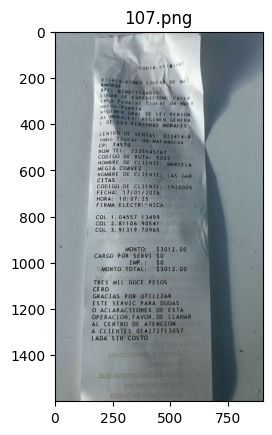

In [ ]:
# Extraccion de Columna de Archivo al azar
# Para probar las funciones de extraccion y 
# la efectividad del entrenamiento

nrandom = random.randint(0, len(ARCHIVOS) - 1)
file_name =  "107.png"
path = os.path.join(FOLDER_PATH, file_name)

# Leer Imagen
image = cv2.imread(path)

plt.imshow(image)
plt.title(file_name)

# Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
# en porcentajes relativos a las dimensiones 
h, w = image.shape[:2] 

# Aplicar Modelo d DocTR a Imagen
resultsDocTR = predictor([image])
print("1er Intento -> Imagen Original , Buscando Columnas")
cols, resultcode = extraer_cols(resultsDocTR, True)
if resultcode != CODE_SUCCESS:
    print("2do Intento -> Imagen Clarificada , Buscando Columnas")
    image_clean = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
    resultsDocTR_clean = predictor([image_clean])
    cols, resultcode = extraer_cols(resultsDocTR_clean, False)
    if resultcode != CODE_SUCCESS :
        print("3er Intento -> Iamgen Original,  Buscando Bloques de 5 digitos entre Etiquetas")
        # Obtener bloques de Texto donde se ubica el codigo 
        bloquesDocTR, minscoreDocTR, (top, bottom), resultcode = getBloquesTextoEntreEtiquetasDocTR(resultsDocTR, w, h, True)
        if resultcode != CODE_SUCCESS :
            print("4to Intento -> Iamgen Clarificada,  Buscando Bloques de 5 digitos entre Etiquetas")
            bloquesDocTR, minscoreDocTR, (top, bottom), resultcode = getBloquesTextoEntreEtiquetasDocTR(resultsDocTR_clean, w, h, False)
            if resultcode == CODE_SUCCESS :
                cols, resultcode = getCodigoBloquesDigitos(bloquesDocTR, "")
        else :
            cols, resultcode = getCodigoBloquesDigitos(bloquesDocTR, "")
           

    
print(cols)

In [ ]:
# Obtener los codigos de todos los tickets
# utilizando como primera opcion la funcion de extraer_cols
# con la imagen original, luego intentar con las misma
# clarificando la imagen y por ultimo intentar tambien
# con la funciones de extraer columnas con la ayuda 
# de etiquetas LABELS_START y LABELS_END

resultados = []

for archivo in ARCHIVOS:

    path = os.path.join(FOLDER_PATH, archivo)

    # Leer Imagen
    image = cv2.imread(path)
    
    # Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
    # en porcentajes relativos a las dimensiones y no en pixeles
    h, w = image.shape[:2] 

    # Aplicar Modelo d DocTR a Imagen Original
    resultsDocTR = predictor([image])
    # Intentar extraer columnas de codigo si columnas se detectaron en la misma linea
    cols, resultcode = extraer_cols(resultsDocTR, False)
    if resultcode != CODE_SUCCESS:
        # Intentar clarificando imagen
        image_clean = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
        resultsDocTR_clean = predictor([image_clean])
        cols, resultcode = extraer_cols(resultsDocTR_clean, False)
        if resultcode != CODE_SUCCESS :
            # Intentar extraer columnas considerando que no estan en la misma linea
            # buscando bloques de 5 digitos entre etiquetas LABELS_START y LABELS_END
            # ordenando bloques por localizacion (x, y)
            # Intentar con resultados de imagen original
            bloquesDocTR, minscoreDocTR, (top, bottom), resultcode = getBloquesTextoEntreEtiquetasDocTR(resultsDocTR, w, h, False)
            if resultcode != CODE_SUCCESS :
                # Reintentar con resultados de Imagen Clarificada
                bloquesDocTR, minscoreDocTR, (top, bottom), resultcode = getBloquesTextoEntreEtiquetasDocTR(resultsDocTR_clean, w, h, False)
                if resultcode == CODE_SUCCESS :
                    cols, resultcode = getCodigoBloquesDigitos(bloquesDocTR, "")
            else :
                cols, resultcode = getCodigoBloquesDigitos(bloquesDocTR, "")

    COL_1 = "COL 1. " + cols[0]
    COL_2 = "COL 2. " + cols[1]
    COL_3 = "COL 3. " + cols[2]

    resultado = {
        RESULTADO_ARCHIVO : archivo,
        RESULTADO_COL_1 : COL_1,
        RESULTADO_COL_2 : COL_2,
        RESULTADO_COL_3 : COL_3
    }

    print(len(resultados) , resultado)

    resultados.append(resultado)
   

0 {'archivo': '1.jpeg', 'COL_1': '15355 50899', 'COL_2': '01146 94344', 'COL_3': '01816 44947'}
1 {'archivo': '10.jpeg', 'COL_1': '15869 47453', 'COL_2': '66601 50814', 'COL_3': '56408 09133'}
2 {'archivo': '100.jpg', 'COL_1': '24421 97889', 'COL_2': '30669 56415', 'COL_3': '69800 86140'}
3 {'archivo': '101.png', 'COL_1': '96476 05643', 'COL_2': '00069 36425', 'COL_3': '60880 89364'}
4 {'archivo': '102.png', 'COL_1': '30556 59450', 'COL_2': '51144 64548', 'COL_3': '91826 13568'}
5 {'archivo': '103.png', 'COL_1': '94051 62662', 'COL_2': '20063 66578', 'COL_3': '60850 53968'}
6 {'archivo': '104.png', 'COL_1': '39506 74158', 'COL_2': '81117 91571', 'COL_3': '91374 12101'}
7 {'archivo': '105.png', 'COL_1': '18889 27246', 'COL_2': '06600 50810', 'COL_3': '56408 06798'}
8 {'archivo': '106.png', 'COL_1': '25354 80796', 'COL_2': '30118 91341', 'COL_3': '41712 94858'}
9 {'archivo': '107.png', 'COL_1': '***** *****', 'COL_2': '***** *****', 'COL_3': '***** *****'}
10 {'archivo': '108.png', 'COL_

In [ ]:
# COnvertir resultados en Dataframe
df_tickets_ext = pd.DataFrame(resultados)
df_tickets_ext


,archivo,COL_1,COL_2,COL_3
0,1.jpeg,15355 50899,01146 94344,01816 44947
1,10.jpeg,15869 47453,66601 50814,56408 09133
2,100.jpg,24421 97889,30669 56415,69800 86140
3,101.png,96476 05643,00069 36425,60880 89364
4,102.png,30556 59450,51144 64548,91826 13568
...,...,...,...,...
845,base64decoded - 2026-01-21T164518.946.jfif,68503 39655,71089 66572,90850 76433
846,base64decoded - 2026-01-21T164527.165.jfif,46562 89368,10156 63543,61523 58744
847,base64decoded - 2026-01-21T164535.581.jpg,85416 14130,60133 91470,91374 88778
848,base64decoded - 2026-01-21T164543.932.jpeg,43524 50105,23130 91543,61314 30170


In [289]:
df_tickets_ext

,archivo,COL_1,COL_2,COL_3
0,1.jpeg,COL 1. 15355 50899,COL 2. 01146 94344,COL 3. 01816 44947
1,10.jpeg,COL 1. 15869 47453,COL 2. 66601 50814,COL 3. 56408 09133
2,100.jpg,COL 1. 24421 97889,COL 2. 30669 56415,COL 3. 69800 86140
3,101.png,COL 1. 96476 05643,COL 2. 00069 36425,COL 3. 60880 89364
4,102.png,COL 1. 30556 59450,COL 2. 51144 64548,COL 3. 91826 13568
...,...,...,...,...
845,base64decoded - 2026-01-21T164518.946.jfif,COL 1. 68503 39655,COL 2. 71089 66572,COL 3. 90850 76433
846,base64decoded - 2026-01-21T164527.165.jfif,COL 1. 46562 89368,COL 2. 10156 63543,COL 3. 61523 58744
847,base64decoded - 2026-01-21T164535.581.jpg,COL 1. 85416 14130,COL 2. 60133 91470,COL 3. 91374 88778
848,base64decoded - 2026-01-21T164543.932.jpeg,COL 1. 43524 50105,COL 2. 23130 91543,COL 3. 61314 30170


In [ ]:
# Grabar resultados a archivo CSV
df_tickets_ext.to_csv(TICKETS_EXT_PATH , index=False)

In [291]:
# Leer archivo de codigos extraidos para crear Dataframe
df_tickets_extraidos = pd.read_csv(TICKETS_EXT_PATH)
df_tickets_extraidos

,archivo,COL_1,COL_2,COL_3
0,1.jpeg,COL 1. 15355 50899,COL 2. 01146 94344,COL 3. 01816 44947
1,10.jpeg,COL 1. 15869 47453,COL 2. 66601 50814,COL 3. 56408 09133
2,100.jpg,COL 1. 24421 97889,COL 2. 30669 56415,COL 3. 69800 86140
3,101.png,COL 1. 96476 05643,COL 2. 00069 36425,COL 3. 60880 89364
4,102.png,COL 1. 30556 59450,COL 2. 51144 64548,COL 3. 91826 13568
...,...,...,...,...
845,base64decoded - 2026-01-21T164518.946.jfif,COL 1. 68503 39655,COL 2. 71089 66572,COL 3. 90850 76433
846,base64decoded - 2026-01-21T164527.165.jfif,COL 1. 46562 89368,COL 2. 10156 63543,COL 3. 61523 58744
847,base64decoded - 2026-01-21T164535.581.jpg,COL 1. 85416 14130,COL 2. 60133 91470,COL 3. 91374 88778
848,base64decoded - 2026-01-21T164543.932.jpeg,COL 1. 43524 50105,COL 2. 23130 91543,COL 3. 61314 30170


In [342]:
# Unir dataframes de codigos reales y codigos extraidos para su comparacion
df_merge = pd.merge(df_tickets, df_tickets_extraidos, on="archivo", how='inner')
df_merge


,archivo,COL_1_x,COL_2_x,COL_3_x,COL_1_y,COL_2_y,COL_3_y
0,348.png,COL 1. 12837 92743,COL 2. 56300 00894,COL 3. 53535 08851,COL 1. 12837 92743,COL 2. 56300 00894,COL 3. 53535 08851
1,374.png,COL 1. 16579 72589,COL 2. 71314 01595,COL 3. 63531 14034,COL 1. 16579 72589,COL 2. 71314 01595,COL 3. 63531 14034
2,base64decoded - 2026-01-21T151846.052.png,COL 1. 64806 06062,COL 2. 16007 20851,COL 3. 50498 02985,COL 1. 64806 06062,COL 2. 16007 20851,COL 3. 50498 02985
3,360.png,COL 1. 82359 81604,COL 2. 63366 06595,COL 3. 83830 34528,COL 1. 82359 81604,COL 2. 63366 06595,COL 3. 83830 34528
4,base64decoded - 2026-01-21T154223.919.png,COL 1. 16189 17608,COL 2. 41667 56315,COL 3. 86800 46054,COL 1. 16189 17608,COL 2. 41667 56315,COL 3. 86800 46054
...,...,...,...,...,...,...,...
840,379.png,COL 1. 71149 18004,COL 2. 71008 30322,COL 3. 40389 48927,COL 1. 71149 18004,COL 2. 71008 30322,COL 3. 40389 48927
841,base64decoded (80).png,COL 1. 50724 30469,COL 2. 31109 90740,COL 3. 61319 28012,COL 1. 50724 30469,COL 2. 31109 90740,COL 3. 61319 28012
842,base64decoded - 2026-01-21T154206.619.png,COL 1. 47551 37002,COL 2. 50609 50516,COL 3. 46505 55624,COL 1. 47551 37002,COL 2. 50609 50516,COL 3. 46505 55624
843,351.png,COL 1. 21502 94050,COL 2. 51106 90571,COL 3. 91478 71673,COL 1. 21502 94050,COL 2. 51106 90571,COL 3. 91478 71673


In [343]:
# COmparar Columnas de Codigos Reales Vs Codigos Extraidos
# Generar un archivo CSV con los resultados

results = []
for ticket in df_merge.itertuples() :

    COMP_COL_1 = False
    if "*" not in ticket.COL_1_y :
        COMP_COL_1 = ticket.COL_1_x == ticket.COL_1_y

    COMP_COL_2 = False
    if "*" not in ticket.COL_2_y :
        COMP_COL_2 = ticket.COL_2_x == ticket.COL_2_y

    COMP_COL_3 = False
    if "*" not in ticket.COL_3_y :
        COMP_COL_3 = ticket.COL_3_x == ticket.COL_3_y

    COMP_TICKET = COMP_COL_1 and COMP_COL_2 and COMP_COL_3

    result = {
        "archivo" : ticket.archivo,
        "COL_1_REAL" : ticket.COL_1_x,
        "COL_1_EXT" : ticket.COL_1_y,
        "COMP_COL_1" : COMP_COL_1,
        "COL_2_REAL" : ticket.COL_2_x,
        "COL_2_EXT" : ticket.COL_2_y,
        "COMP_COL_2" : COMP_COL_2,
        "COL_3_REAL" : ticket.COL_3_x,
        "COL_3_EXT" : ticket.COL_3_y,
        "COMP_COL_3" : COMP_COL_3,
        "CODIGO_COMP" : COMP_TICKET
    }

    results.append(result)
    
df_result_comp = pd.DataFrame(results)
df_result_comp
df_result_comp.to_csv(r"C:\Users\arant\Downloads\doctr\efectividadDoctr3.csv" , index=False)

In [344]:
df_ticket_ok = df_result_comp[df_result_comp["CODIGO_COMP"]==True]
df_ticket_ok

,archivo,COL_1_REAL,COL_1_EXT,COMP_COL_1,COL_2_REAL,COL_2_EXT,COMP_COL_2,COL_3_REAL,COL_3_EXT,COMP_COL_3,CODIGO_COMP
0,348.png,COL 1. 12837 92743,COL 1. 12837 92743,True,COL 2. 56300 00894,COL 2. 56300 00894,True,COL 3. 53535 08851,COL 3. 53535 08851,True,True
1,374.png,COL 1. 16579 72589,COL 1. 16579 72589,True,COL 2. 71314 01595,COL 2. 71314 01595,True,COL 3. 63531 14034,COL 3. 63531 14034,True,True
2,base64decoded - 2026-01-21T151846.052.png,COL 1. 64806 06062,COL 1. 64806 06062,True,COL 2. 16007 20851,COL 2. 16007 20851,True,COL 3. 50498 02985,COL 3. 50498 02985,True,True
3,360.png,COL 1. 82359 81604,COL 1. 82359 81604,True,COL 2. 63366 06595,COL 2. 63366 06595,True,COL 3. 83830 34528,COL 3. 83830 34528,True,True
4,base64decoded - 2026-01-21T154223.919.png,COL 1. 16189 17608,COL 1. 16189 17608,True,COL 2. 41667 56315,COL 2. 41667 56315,True,COL 3. 86800 46054,COL 3. 86800 46054,True,True
...,...,...,...,...,...,...,...,...,...,...,...
840,379.png,COL 1. 71149 18004,COL 1. 71149 18004,True,COL 2. 71008 30322,COL 2. 71008 30322,True,COL 3. 40389 48927,COL 3. 40389 48927,True,True
841,base64decoded (80).png,COL 1. 50724 30469,COL 1. 50724 30469,True,COL 2. 31109 90740,COL 2. 31109 90740,True,COL 3. 61319 28012,COL 3. 61319 28012,True,True
842,base64decoded - 2026-01-21T154206.619.png,COL 1. 47551 37002,COL 1. 47551 37002,True,COL 2. 50609 50516,COL 2. 50609 50516,True,COL 3. 46505 55624,COL 3. 46505 55624,True,True
843,351.png,COL 1. 21502 94050,COL 1. 21502 94050,True,COL 2. 51106 90571,COL 2. 51106 90571,True,COL 3. 91478 71673,COL 3. 91478 71673,True,True


In [345]:
df_ticket_error = df_result_comp[df_result_comp["CODIGO_COMP"]==False]
df_ticket_error

,archivo,COL_1_REAL,COL_1_EXT,COMP_COL_1,COL_2_REAL,COL_2_EXT,COMP_COL_2,COL_3_REAL,COL_3_EXT,COMP_COL_3,CODIGO_COMP
77,base64decoded - 2026-01-21T161143.068.jpg,COL 1. 42339 57138,COL 1. ***** *****,False,COL 2. 31617 51315,COL 2. ***** *****,False,COL 3. 46501 49244,COL 3. ***** *****,False,False
85,base64decoded (76).png,COL 1. 91546 33311,COL 1. ***** *****,False,COL 2. 51430 63554,COL 2. ***** *****,False,COL 3. 94563 11318,COL 3. ***** *****,False,False
87,base64decoded - 2026-01-21T155127.340.png,COL 1. 91870 29158,COL 1. ***** *****,False,COL 2. 76117 61848,COL 2. ***** *****,False,COL 3. 51722 01280,COL 3. ***** *****,False,False
142,96.jfif,COL 1. 99417 79440,COL 1. ***** *****,False,COL 2. 90149 64444,COL 2. ***** *****,False,COL 3. 31826 87897,COL 3. ***** *****,False,False
151,base64decoded - 2026-01-21T162350.709.jpeg,COL 1. 11517 80456,COL 1. ***** *****,False,COL 2. 00149 94546,COL 2. ***** *****,False,COL 3. 21816 56121,COL 3. ***** *****,False,False
166,base64decoded - 2026-01-21T153012.417.png,COL 1. 25416 85970,COL 1. ***** *****,False,COL 2. 00089 36423,COL 2. ***** *****,False,COL 3. 30583 81482,COL 3. ***** *****,False,False
199,base64decoded - 2026-01-21T155930.685.png,COL 1. 42587 97328,COL 1. ***** *****,False,COL 2. 31610 51511,COL 2. ***** *****,False,COL 3. 96304 77711,COL 3. ***** *****,False,False
221,base64decoded - 2026-01-21T151818.252.png,COL 1. 91543 89050,COL 1. ***** *****,False,COL 2. 33002 60570,COL 2. ***** *****,False,COL 3. 00458 37848,COL 3. ***** *****,False,False
237,base64decoded - 2026-01-21T153931.941.png,COL 1. 44581 63691,COL 1. ***** *****,False,COL 2. 41464 66555,COL 2. ***** *****,False,COL 3. 84860 70593,COL 3. ***** *****,False,False
238,base64decoded - 2026-01-21T163824.960.png,COL 1. 04406 93141,COL 1. ***** *****,False,COL 2. 90433 61450,COL 2. ***** *****,False,COL 3. 24364 84619,COL 3. ***** *****,False,False


In [ ]:
# Revision de Tickets con Error Ejecute el numero de veces segun numero de tickets errados
n = 0
tickets_errados = len(df_ticket_error)

1er Intento -> Imagen Original , Buscando Columnas
RFC: BIM011108DJ5
vard 5 de Febrero
LUGAR DE EXPEDICION: Boule
REGIMEN GRAL DE LEY PERSON
AS MORALES: REGIMEN GENERA
L DE LEY PERSONAS MORALES
CENTRO DE VENTAS: 023669-B
imbo San Andres
CP: 95740
NUM TEL: 2949421451
CODIGO DE RUTA: 1101
NOMBRE DE CLIENTE: BENJAMIN
NOMBRE DE CLIENTE: DON BEN
CODIGO DE CLIENTE: 246603
CRUZ JUAN
JA
FECHA: 20/01/2026
HORA: 16:17:32
COL 1.52544 72110
COL 2.11359 01592
COL 3.93531 71689
MONTO: $3012.00
IMP.: $0.0
CARGO POR SERVI $0.0
MONTO TOTAL: $3012
TRES MIL DOCE PESOS
CERO
GRACIAS POR UTILIZAR
ESTE SERVIC PARA DUDAS
0 ACLARACTIONES DE ESTA
OPERACION, FAVOR,DE LLAHAR
AL CENTRO DE ATENCION
A CLIENTES 014272713057
LADA SIN COSTO
['52544 72110', '11359 01592', '93531 71689']


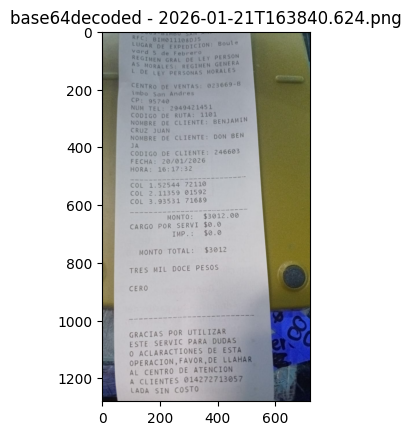

In [339]:

if n<tickets_errados :

    file_name =  df_ticket_error.iloc[n][RESULTADO_ARCHIVO]

    path = os.path.join(FOLDER_PATH, file_name)

    # Leer Imagen
    image = cv2.imread(path)

    plt.imshow(image)
    plt.title(file_name)

    # Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
    # en porcentajes relativos a las dimensiones 
    h, w = image.shape[:2] 

    # Aplicar Modelo d DocTR a Imagen
    resultsDocTR = predictor([image])
    print("1er Intento -> Imagen Original , Buscando Columnas")
    cols, resultcode = extraer_cols(resultsDocTR, True)
    if resultcode != CODE_SUCCESS:
        print("2do Intento -> Imagen Clarificada , Buscando Columnas")
        image_clean = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
        resultsDocTR_clean = predictor([image_clean])
        cols, resultcode = extraer_cols(resultsDocTR_clean, False)
        if resultcode != CODE_SUCCESS :
            print("3er Intento -> Iamgen Original,  Buscando Bloques de 5 digitos entre Etiquetas")
            # Obtener bloques de Texto donde se ubica el codigo 
            bloquesDocTR, minscoreDocTR, (top, bottom), resultcode = getBloquesTextoEntreEtiquetasDocTR(resultsDocTR, w, h, True)
            if resultcode != CODE_SUCCESS :
                print("4to Intento -> Iamgen Clarificada,  Buscando Bloques de 5 digitos entre Etiquetas")
                bloquesDocTR, minscoreDocTR, (top, bottom), resultcode = getBloquesTextoEntreEtiquetasDocTR(resultsDocTR_clean, w, h, False)
                if resultcode == CODE_SUCCESS :
                    cols, resultcode = getCodigoBloquesDigitos(bloquesDocTR, "")
            else :
                cols, resultcode = getCodigoBloquesDigitos(bloquesDocTR, "")
            

    
    print(cols)

    n += 1

else :
    print("Finalizo revision de tickets errados")

In [347]:
# Obtencion Manual de Codigos para generar archivos de entrenamiento
n = 1

# Modelo OCR de DOCTR
model = ocr_predictor('db_resnet50', 'crnn_vgg16_bn', pretrained=True)

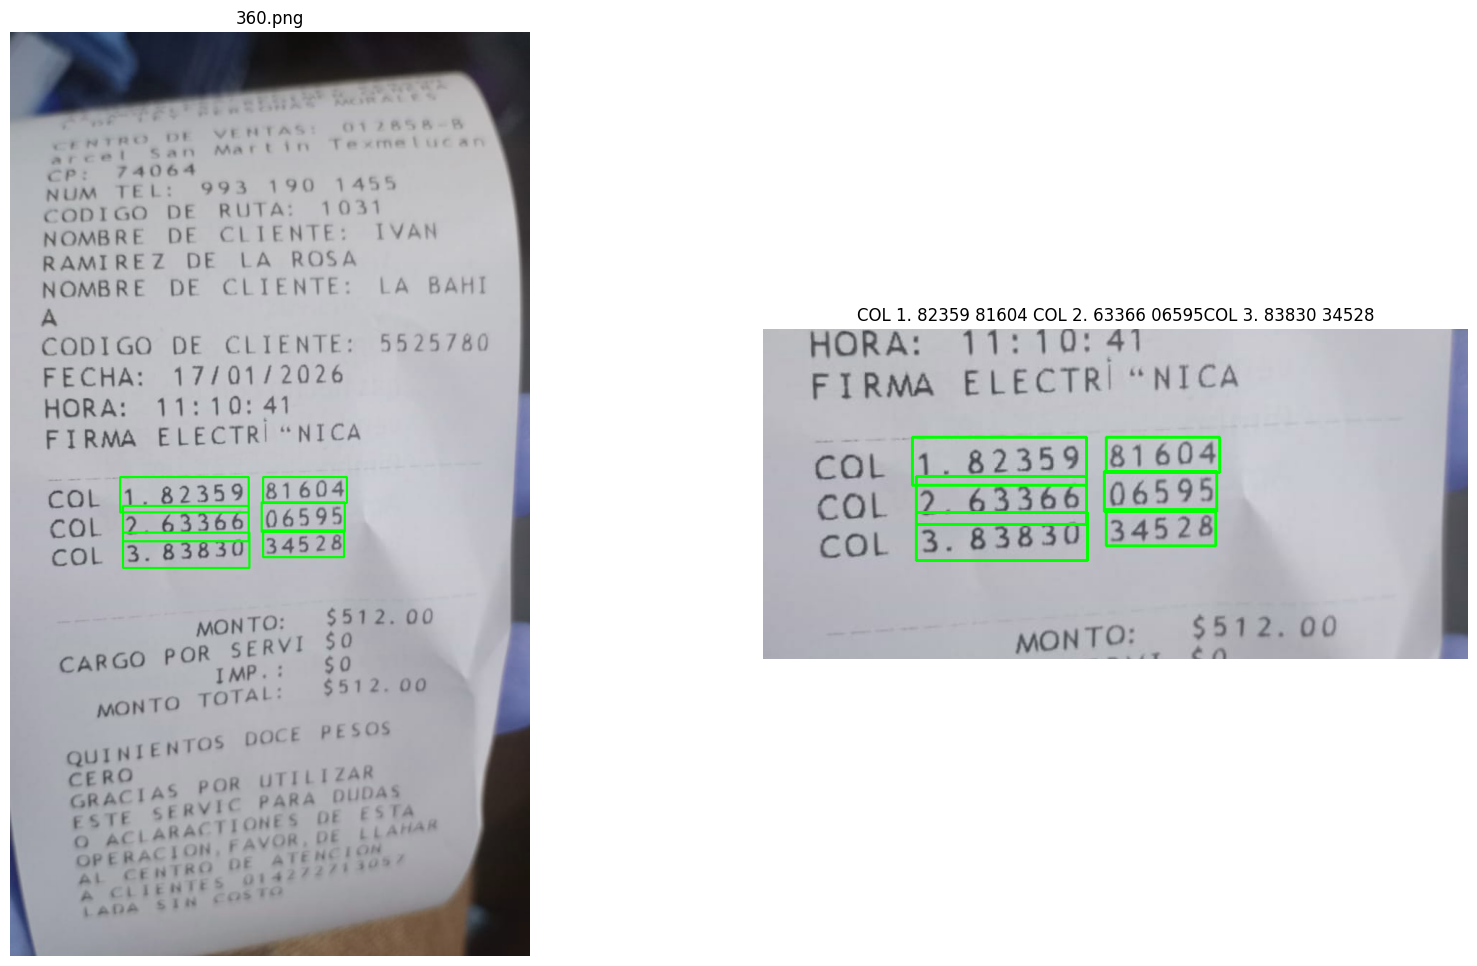

3
COL 1. 82359 81604
COL 2. 63366 06595
COL 3. 83830 34528


In [351]:
ticket = df_tickets.iloc[n]
file_name = ticket[RESULTADO_ARCHIVO]
image = cv2.imread(f"{FOLDER_PATH}/{file_name}")


# Obtener dimensiones de imagen , se requieren porque DOCTR regresa coordenadas de ubicacion del texto 
# en porcentajes relativos a las dimensiones 
h, w = image.shape[:2] 

# Aplicar Modelo d DocTR a Imagen
resultsDocTR = model([image])

# Obtener bloques de Texto donde se ubica el codigo 
bloquesDocTR, minscoreDocTR, (top, bottom), resultcodeDocTR = getBloquesTextoEntreEtiquetasDocTR(resultsDocTR, w, h, False)


# Mostrar Rectangulo alrededor de los bloques de Texto del presunto codigo detectados
for bloque in bloquesDocTR :
    cv2.rectangle(image, (bloque[0][0]), (bloque[0][1]), (0,255,0), 2)


recorte = image[top:bottom, 0:w]

cod = ticket.COL_1 + " " + ticket.COL_2 + ticket.COL_3

# Mostrar Imagenes resultantes
plt.figure(figsize=(20, 12))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(file_name)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(recorte)
plt.title(cod)
plt.axis('off')
plt.show()


print(n)
print(ticket["COL_1"])
print(ticket["COL_2"])
print(ticket["COL_3"])


n += 1
